# 1. Data loading

### 1.1 Importing modules

In [58]:
# import all modules
import pandas as pd
import geopandas as gpd
import requests
import matplotlib.pyplot as plt
!pip install contextily
import contextily as cx

In [78]:
wildfire_gdf.describe()

,latitude,longitude,bright_ti4,scan,track,acq_time,bright_ti5,frp,frp_raw,frp_vis,frp_without_min
count,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000
mean,10.196337,56.188756,342.349688,0.478000,0.503927,934.959633,304.596826,89.444881,89.444881,89.113804,89.444881
std,30.318320,85.578105,31.387709,0.100584,0.124131,603.540100,17.075304,43.882103,43.882103,42.593847,43.882103
min,-42.414490,-120.797250,207.930000,0.320000,0.360000,56.000000,262.450000,50.130000,50.130000,50.130000,50.130000
25%,-14.972920,-11.486560,338.490000,0.390000,0.380000,417.000000,293.700000,59.430000,59.430000,59.430000,59.430000
50%,10.920870,112.804890,347.630000,0.450000,0.490000,548.000000,302.400000,72.490000,72.490000,72.490000,72.490000
75%,46.091260,127.466160,356.160000,0.560000,0.570000,1414.000000,313.170000,100.820000,100.820000,100.820000,100.820000
max,61.352660,160.599330,367.000000,0.740000,0.760000,2320.000000,376.240000,291.570000,291.570000,234.857200,291.570000


In [59]:
area_url='https://firms.modaps.eosdis.nasa.gov/api/area/csv/38064bff4711161d2878baf2b432ef5f/VIIRS_NOAA20_NRT/world/2'

response=requests.get(area_url)
# print(response.text) #here I saw that its already plain text and not json to parse, no .json() to unpack required

#Check
if response.status_code==200:
      print("Request worked")
else:
      print("Request did not work")

# Create dataframe
df_area = pd.read_csv(area_url)
df_area

Request worked


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
0,55.96853,160.59933,367.00,0.59,0.53,2026-05-14,56,N20,VIIRS,h,2.0NRT,310.43,50.48,D
1,64.64521,24.42407,329.33,0.39,0.36,2026-05-14,109,N20,VIIRS,n,2.0NRT,281.26,3.20,N
2,64.64832,24.42700,295.40,0.39,0.36,2026-05-14,109,N20,VIIRS,n,2.0NRT,279.35,0.68,N
3,64.65274,24.42233,308.33,0.39,0.36,2026-05-14,109,N20,VIIRS,n,2.0NRT,279.48,0.68,N
4,52.53268,39.63256,313.27,0.76,0.77,2026-05-14,111,N20,VIIRS,n,2.0NRT,260.49,2.35,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43553,20.95893,-104.22726,309.80,0.63,0.72,2026-05-15,932,N20,VIIRS,n,2.0NRT,285.49,1.87,N
43554,20.96022,-104.23267,300.33,0.63,0.72,2026-05-15,932,N20,VIIRS,n,2.0NRT,284.67,1.87,N
43555,20.96024,-104.23314,297.84,0.63,0.72,2026-05-15,932,N20,VIIRS,n,2.0NRT,284.77,1.82,N
43556,21.03221,-104.98219,303.19,0.56,0.69,2026-05-15,932,N20,VIIRS,n,2.0NRT,290.57,1.59,N


# 2. Data cleaning

In [60]:
wildfire_gdf=gpd.GeoDataFrame(df_area, geometry=gpd.points_from_xy(df_area["longitude"], df_area["latitude"]), crs=(4326))
wildfire_gdf.head(3)

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,geometry
0,55.96853,160.59933,367.00,0.59,0.53,2026-05-14,56,N20,VIIRS,h,2.0NRT,310.43,50.48,D,POINT (160.59933 55.96853)
1,64.64521,24.42407,329.33,0.39,0.36,2026-05-14,109,N20,VIIRS,n,2.0NRT,281.26,3.20,N,POINT (24.42407 64.64521)
2,64.64832,24.42700,295.40,0.39,0.36,2026-05-14,109,N20,VIIRS,n,2.0NRT,279.35,0.68,N,POINT (24.427 64.64832)


# 3. Spatial analysis

In [61]:
#Classify wildfire strength
wildfire_gdf["frp"].head(3)
wildfire_gdf["frp"].describe()


count    43558.000000
mean         7.731023
std         12.468453
min          0.000000
25%          2.540000
50%          4.670000
75%          8.300000
max        291.570000
Name: frp, dtype: float64

In [83]:
#Cut off extremes, differentiate between frp_raw for analysis, and frp_vis for visualization

wildfire_gdf = wildfire_gdf[wildfire_gdf["frp"] > 30].copy()

wildfire_gdf["frp_raw"] = wildfire_gdf["frp"]

upper = wildfire_gdf["frp"].quantile(0.99)

wildfire_gdf["frp_vis"] = wildfire_gdf["frp"].clip(upper=upper)

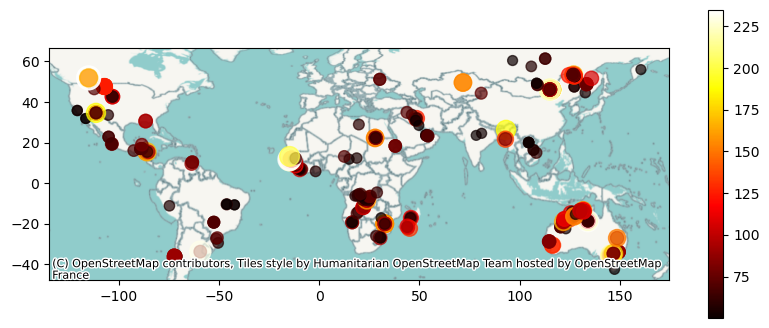

In [84]:
#With normalization
import contextily as cx

fig, ax= plt.subplots(figsize=(10,4))

wildfire_gdf.plot(ax=ax, column="frp_vis", cmap="hot", markersize="frp_raw", alpha=0.7, legend=True)

cx.add_basemap(
    ax,
    crs="EPSG:4326"
)


<function matplotlib.pyplot.show(close=None, block=None)>

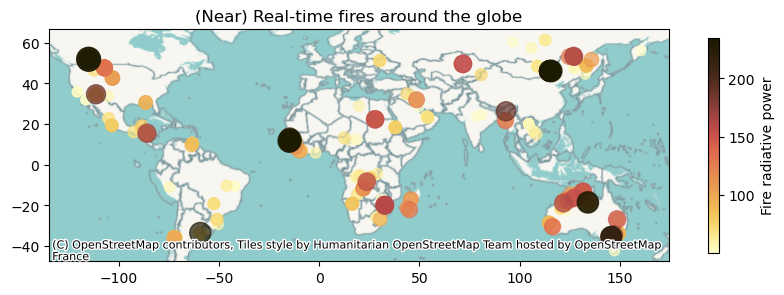

In [85]:
import cmcrameri.cm as cmc
#cmc lipari or OrRd or lajolla

wildfire_gdf_sorted=wildfire_gdf.sort_values("frp_vis")

fig, ax= plt.subplots(figsize=(10,4))

legend_options= legend_options = { "label": "Fire radiative power", "orientation": "vertical", "shrink": 0.7}
wildfire_gdf_sorted.plot(ax=ax, column="frp_vis", cmap="cmc.lajolla_r", markersize="frp", alpha=0.7, legend=True, legend_kwds=legend_options)
cx.add_basemap(ax=ax, crs=4326)
plt.title("(Near) Real-time fires around the globe")
plt.show

In [26]:
#Introduce uncertainty with transparency
wildfire_gdf["confidence"].unique()

import numpy as np

wildfire_gdf["alpha"] = np.select(
    [
        wildfire_gdf["confidence"] == "h",
        wildfire_gdf["confidence"] == "n",
        wildfire_gdf["confidence"] == "l",
    ],
    [
        1.0,
        0.7,
        0.4
    ],
    default=0.5
)

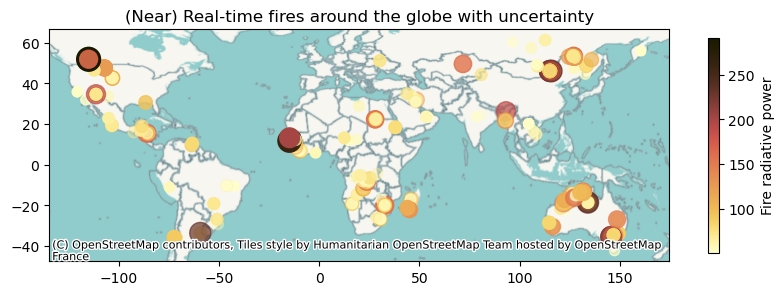

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx
import cmcrameri.cm as cmc

# -------------------------
# 1. Filter FRP
# -------------------------
wildfire_gdf = wildfire_gdf[wildfire_gdf["frp"] > 50].copy()

# -------------------------
# 2. Map confidence → alpha
# -------------------------
wildfire_gdf["alpha"] = np.select(
    [
        wildfire_gdf["confidence"] == "h",
        wildfire_gdf["confidence"] == "n",
        wildfire_gdf["confidence"] == "l",
    ],
    [
        1.0,
        0.7,
        0.4
    ],
    default=0.5
)

# -------------------------
# 3. Scale FRP for marker size
# -------------------------
wildfire_gdf["size"] = wildfire_gdf["frp"]

# -------------------------
# 4. Plot
# -------------------------
fig, ax = plt.subplots(figsize=(10, 4))

wildfire_gdf.plot(
    ax=ax,
    column="frp",
    cmap=cmc.lajolla_r,
    markersize=wildfire_gdf["size"],
    alpha=wildfire_gdf["alpha"],   # 👈 uncertainty here
    legend=True,
    legend_kwds={
        "label": "Fire radiative power",
        "orientation": "vertical",
        "shrink": 0.7
    }
)

# Basemap (correct CRS assumed EPSG:4326 -> 3857)
cx.add_basemap(ax=ax, crs=wildfire_gdf.crs)

plt.title("(Near) Real-time fires around the globe with uncertainty")
plt.show()

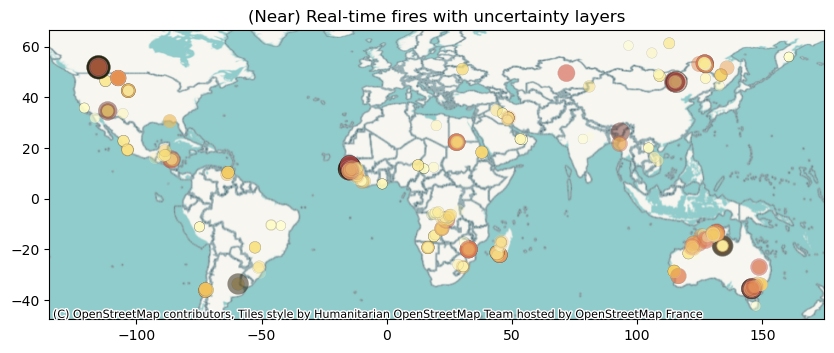

In [35]:
import matplotlib.pyplot as plt
import contextily as cx
import cmcrameri.cm as cmc

# Filter
wildfire_gdf = wildfire_gdf[wildfire_gdf["frp"] > 50].copy()

# Size scaling
wildfire_gdf["size"] = wildfire_gdf["frp"]

# Split datasets
high = wildfire_gdf[wildfire_gdf["confidence"] == "h"]
nominal = wildfire_gdf[wildfire_gdf["confidence"] == "n"]
low = wildfire_gdf[wildfire_gdf["confidence"] == "l"]

fig, ax = plt.subplots(figsize=(10, 5))

# -------------------
# High confidence (solid)
# -------------------
high.plot(
    ax=ax,
    column="frp",
    cmap=cmc.lajolla_r,
    markersize=high["size"],
    alpha=0.9,
    legend=False,
    edgecolor="black",
    linewidth=0.2
)

# -------------------
# Nominal confidence (dashed feel)
# -------------------
nominal.plot(
    ax=ax,
    column="frp",
    cmap=cmc.lajolla_r,
    markersize=nominal["size"],
    alpha=0.5,
    legend=False,
    edgecolor="gray",
    linewidth=0.2
)

# -------------------
# Low confidence (faint + gray outline)
# -------------------
low.plot(
    ax=ax,
    column="frp",
    cmap=cmc.lajolla_r,
    markersize=low["size"],
    alpha=0.25,
    legend=False,
    edgecolor="white",
    linewidth=0.3
)

# Basemap
cx.add_basemap(ax=ax, crs=wildfire_gdf.crs)

plt.title("(Near) Real-time fires with uncertainty layers")
plt.show()

In [ ]:
# Next step: Do proper map, with normalizing, making classification, handling missing values and so on using this code and practicals VL8
# import geopandas as gpd
# import matplotlib.pyplot as plt
# import cmcrameri.cm as cmc
# import numpy as np

# # 1. Setup
# fig, ax = plt.subplots(figsize=(12, 10))

# # 4. Legend options
# legend_options = {
#     "label": "Ratio: Women per 100 Men",
#     "orientation": "vertical",
#     "shrink": 0.7
# }

# # 6. Missing data options
# missing_styling = {
#     "color": "#EEEEEE",
#     "label": "No Data"
# }

# # 2, 3, 5. Plot the choropleth
# nuts.plot(
#     ax=ax,
#     column="women_per100men",
#     cmap=cmc.vik, 
#     vmin=vmin,
#     vmax=vmax,
#     legend=True,
#     legend_kwds=legend_options,
#     missing_kwds=missing_styling,
#     edgecolor="black",
#     linewidth=0.1
# )

# # 7. Formatting
# ax.set_title("Gender Ratio Across European Regions", fontsize=16)
# ax.axis("off")
ax.grid(True)

# plt.show()

# 4. Visualization

In [94]:
# Best interactive map until now

import numpy as np
import folium
import matplotlib.cm as cm
import matplotlib.colors as colors

# SORT (big fires last → on top)
wildfire_filtered = wildfire_filtered.sort_values("frp_vis", ascending=True)

# Color scale based on VISUAL values
vmin = wildfire_filtered["frp_vis"].min()
vmax = wildfire_filtered["frp_vis"].max()

norm = colors.Normalize(vmin=vmin, vmax=vmax)
cmap = cm.get_cmap("YlOrRd")

# Map (dark background)
m = folium.Map(
    location=[20, 0],
    zoom_start=2,
    tiles="CartoDB dark_matter",
    #control_scale=True
)


for _, row in wildfire_filtered.iterrows():

    frp = row["frp_vis"]

    # SIZE (direct scaling, no sqrt/log)
    radius = max(frp / 10, 2)

    # COLOR (based on same variable)
    color = colors.to_hex(cmap(norm(frp)))

    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=radius,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.75,
        popup=f"FRP [MW]: {row['frp']:.1f},  Date: {row['acq_date']}"
    ).add_to(m)

m.save("wildfire2.html")

C:\Users\Javier Feller\AppData\Local\Temp\ipykernel_39568\3001905583.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("YlOrRd")
